# Equilibrium LOB Shape for a Polymarket Digital Option
## Unified Trader Mean-Field Game with Ma-Noh Dynamics

---

**What this notebook computes.** The equilibrium shape of the ask-side limit order book $\mathcal{D}(a)$ for a binary contract on Polymarket. A single population of traders, each with a valuation $v \sim \text{Beta}(\alpha_F, \beta_F)$ and discount rate $r \sim \text{Uniform}[r_{\min}, r_{\max}]$, endogenously sorts into market-order submitters and limit-order providers. The LOB shape emerges from the interaction of Bertrand price competition and Ma-Noh mean-field liquidity dynamics.

---
# Part I: The Market

## §1. The Polymarket Digital Option

Polymarket hosts binary prediction markets. A contract — e.g. *"Will BTC exceed \$100K by Dec 31?"* — has two complementary shares:

$$\text{Payoff}_{YES} = \mathbf{1}\{S_T \ge K\}, \qquad \text{Payoff}_{NO} = 1 - \text{Payoff}_{YES}.$$

Since YES + NO = \$1 always, one price $p \in (0,1)$ summarises the market. Selling YES at $a$ is equivalent to buying NO at $1-a$. **The YES ask-side book contains all the information** — the bid side is its mirror image.

## §2. The Unified Trader Population

**Key modelling choice.** Instead of separate buyer and LP populations, we have a **single population of traders**. Each trader $i$ is characterised by two numbers:

- **Valuation** $v_i \sim F = \text{Beta}(\alpha_F, \beta_F)$ on $[0,1]$ — their subjective probability of the event (what they think the YES share is worth)
- **Discount rate** $r_i \sim G = \text{Uniform}[r_{\min}, r_{\max}]$ — their impatience / cost of capital

Traders arrive at Poisson rate $\lambda$. Upon arrival, a trader observes the current book with best ask $a_{\text{best}}$ and best bid $b_{\text{best}}$, and is classified into one of three roles:

### Classification

1. **Market buyer** (if $v \ge a_{\text{best}}$): the trader values YES above the cheapest offer. They submit a market buy, immediately consuming $\delta$ shares from the ask book. This is a liquidity-consuming event.

2. **Market seller** (if $v \le b_{\text{best}}$): the trader values YES below the highest bid. They submit a market sell, consuming depth from the bid book.

3. **Limit-order provider / LP** (if $b_{\text{best}} < v < a_{\text{best}}$): the trader is "in the spread." They post a limit order and become an LP. Their valuation $v$ determines their effective cost basis, and their discount rate $r$ determines their patience.

### Why this unification matters

The same distribution $F$ simultaneously determines:
- The **demand side**: market order flow $\phi(a) = \lambda[1 - F(a)]$
- The **supply side**: the LP population's cost bases (their valuations $v$)
- The **bid-ask boundary**: who is a buyer vs seller vs LP

All three are linked through a single primitive — the distribution of beliefs about the event probability.

## §3. Market Order Flow

The rate at which market buy orders arrive at ask $a$ is:

$$\phi(a) = \lambda \cdot \Pr(v \ge a) = \lambda[1 - F_{\text{Beta}}(a;\, \alpha_F, \beta_F)]$$

Under Beta(2,2): $\phi(a) = \lambda[1 - I_a(2,2)]$ where $I_a$ is the regularised incomplete beta function. This is:
- Concave and decreasing in $a$
- $\phi(0) = \lambda$ (everyone buys at price 0)
- $\phi(1) = 0$ (no one buys at price 1)
- $\phi(0.5) = \lambda/2$ (by symmetry of Beta(2,2))

Compared to Uniform $F$ (where $\phi(a) = \lambda(1-a)$ is linear), Beta(2,2) puts more weight near the centre and less at the extremes — a more realistic representation of dispersed but centred beliefs.

## §4. The LP's Role and Cost Basis

An ask-side LP is a trader with valuation $v < a_{\text{best}}$ who chooses to post a limit sell order instead of waiting. By posting at ask $a > v$, the LP offers to sell a YES share that they value at $v$ for a price $a > v$. Their **margin per fill** is:

$$\text{margin} = (a - v) \cdot \delta$$

The valuation $v$ plays the role of the cost basis $c$ from the previous framework — but now it is **heterogeneous across LPs**, drawn from $F$. LPs with low $v$ (very bearish) have large potential margins. LPs with $v$ close to the spread have thin margins.

This creates **two-dimensional heterogeneity**: LPs differ in both $v$ (what they think the share is worth) and $r$ (how patient they are). The interaction of these two dimensions generates the LOB shape.

---
# Part II: The LP's Problem

## §5. Depth Dynamics (Ma-Noh)

Fix an LP with $(v, r)$ posting at ask $a$. Their depth $q$ follows a jump process on $\{0, \delta, 2\delta, \ldots\}$:

**Replenishment**: $q \to q + \delta_s$ at rate $l \cdot \Psi(u)$, where $l \in [0, \bar{l}]$ is the control and $\Psi(u) = 1 + \psi u$ depends on the LP's rank $u$ in the sub-population at price $a$.

**Execution**: $q \to (q - \delta_b)^+$ at rate $\mu(a) \cdot \Theta(u)$, where $\mu(a) = \phi(a)/\mathcal{D}(a)$ is the pro-rata fill rate and $\Theta(u) = 1 + \theta(1-u)$.

**Rank coupling**: $\Psi(u)$ and $\Theta(u)$ are the Ma-Noh mean-field interaction. Front-of-queue LPs (low $u$) face more executions; back-of-queue (high $u$) replenish more easily.

## §6. The HJB Equation

The LP's value function $V_i = V(q_i;\, v, r, a)$ satisfies:

$$rV_i = \max_{l \ge 0}\left\{(a-v)\delta_b \lambda_b^i \mathbb{1}_{q_i > 0} - \frac{\kappa}{2}l^2 + l\Psi(u_i)(V_{j^+}-V_i) + \lambda_b^i(V_{j^-}-V_i)\right\}$$

**Optimal control**: $l_i^* = \Pi_{[0,\bar{l}]}\left(\frac{\Psi(u_i)}{\kappa}(V_{j^+}-V_i)\right)$

**Matrix structure**: For fixed $l$, the HJB is $AV = b$ with $A_{ii} = r + \lambda_s^i + \lambda_b^i$ (strictly diagonally dominant, excess = $r > 0$). No normalisation needed — $V_0$ is the genuine expected discounted profit.

**Bertrand objective**: $a^*(v, r) = \arg\max_a V_0(v, r, a, \mu(a))$

The LP chooses the ask that maximises their expected discounted profit from starting empty, taking $\mathcal{D}(a)$ as given.

## §7. KFE and Equilibrium

**KFE**: Given $l^*$, the induced Markov chain has a stationary distribution $m$ satisfying $m^T P = m^T$. The quantile function $Q(u)$ is updated by inverting the CDF of $m$, with damping: $Q^{(k+1)} = (1-\omega)Q^{(k)} + \omega\tilde{Q}$.

**Fixed point on $\mathcal{D}(a)$**: The full equilibrium is:
$$\mathcal{D} \to \mu = \phi/\mathcal{D} \to \text{Ma-Noh}(v, r, \mu) \to \text{Bertrand}(a^*) \to \mathcal{D}$$

**Aggregation**: Each LP type $(v_k, r_j)$ posts at $a^*(v_k, r_j)$ with mean depth $\bar{d}(v_k, r_j)$. The density at ask $a$ is:
$$d(a) = N \int\int \bar{d}(v, r, a) \cdot f(v) \cdot g(r) \cdot \text{kernel}(a - a^*(v,r))\, dv\, dr$$

**From density to LOB**: The cumulative ask depth (what you see on Polymarket) is:
$$\mathcal{D}_{\text{cum}}(a) = \int_a^{a_{\max}} d(s)\, ds$$

**Bid side**: By YES/NO symmetry: $d_{\text{bid}}(b) = d_{\text{ask}}(1-b)$.

---
# Part III: Implementation

In [1]:
import numpy as np
from scipy.stats import beta as beta_dist
import matplotlib.pyplot as plt
import time

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12, 'axes.labelsize': 14,
    'axes.titlesize': 14, 'legend.fontsize': 11, 'lines.linewidth': 2,
    'figure.dpi': 120,
})

## §8. Ma-Noh Functions

In [2]:
def proj_0_lbar(x, lbar):
    return np.minimum(np.maximum(x, 0.0), lbar)

def rank_grid(N):
    return (np.arange(1, N+1) - 0.5) / N

def destination_indices(q, delta_s, delta_b):
    q = np.asarray(q); N = q.size
    j_plus = np.empty(N, dtype=int); j_minus = np.empty(N, dtype=int)
    for i in range(N):
        j_plus[i] = int(np.argmin(np.abs(q - (q[i] + delta_s))))
        j_minus[i] = int(np.argmin(np.abs(q - max(q[i] - delta_b, 0.0))))
    return j_plus, j_minus

def solve_stationary_hjb(q, u, j_plus, j_minus,
                          rho, kappa, l_bar, psi, theta, m_margin, delta_b,
                          phi_b_func=None, max_iter=80, tol=1e-10):
    q = np.asarray(q); u = np.asarray(u); N = q.size
    if phi_b_func is None: phi_b_func = lambda x: np.ones_like(x)
    phi_b_q = phi_b_func(q)
    Psi = 1.0 + psi*u; Theta = 1.0 + theta*(1.0 - u)
    l = np.zeros(N); V = np.zeros(N)
    for it in range(max_iter):
        lam_s = l*Psi; lam_b = phi_b_q*Theta
        pi = m_margin*lam_b*delta_b*(q > 0).astype(float)
        A = np.zeros((N, N)); b = np.zeros(N)
        for i in range(N):
            A[i, i] = rho + lam_s[i] + lam_b[i]
            A[i, j_plus[i]] -= lam_s[i]; A[i, j_minus[i]] -= lam_b[i]
            b[i] = pi[i] - 0.5*kappa*(l[i]**2)
        try: V_new = np.linalg.solve(A, b)
        except: break
        l_raw = (Psi/kappa)*(V_new[j_plus] - V_new)
        l_new = proj_0_lbar(l_raw, l_bar)
        if np.max(np.abs(l_new-l)) < tol and np.max(np.abs(V_new-V)) < tol:
            V, l = V_new, l_new; break
        V, l = V_new, l_new
    return V, l

def stationary_dist(j_plus, j_minus, lam_plus, lam_minus, tol=1e-14, max_iter=80000):
    N = len(lam_plus); rates = np.array(lam_plus)+np.array(lam_minus)
    barL = np.max(rates)+1e-12
    P = np.zeros((N,N))
    for i in range(N):
        if rates[i]>0:
            P[i,j_plus[i]]+=lam_plus[i]/barL; P[i,j_minus[i]]+=lam_minus[i]/barL
            P[i,i]+=1.0-rates[i]/barL
        else: P[i,i]=1.0
    m=np.ones(N)/N; PT=P.T
    for _ in range(max_iter):
        m_new=PT@m; s=m_new.sum()
        if s<=0: break
        m_new/=s
        if np.max(np.abs(m_new-m))<tol: m=m_new; break
        m=m_new
    return m

def quantile_from_masses(u, q, m):
    M=np.cumsum(m); M=np.clip(M,0,1)
    M_eps=M.copy()
    for i in range(1,len(M_eps)):
        if M_eps[i]<=M_eps[i-1]: M_eps[i]=M_eps[i-1]+1e-12
    M_eps=np.clip(M_eps,0,1)
    return np.interp(u,M_eps,q,left=q[0],right=q[-1])

print('Ma-Noh functions loaded.')

Ma-Noh functions loaded.


## §9. Parameters and Inner Solver

In [3]:
alpha_F = 2.0; beta_F = 2.0  # Beta distribution for valuations
lam_arrival = 10.0  # trader arrival rate
delta_s = 1.0; delta_b = 1.0
kappa = 0.4; l_bar = 3.0; psi = 0.3; theta = 0.7
N_total = 100.0; r_min = 0.05; r_max = 2.0

N_v=5; N_r=6; N_a=12; N_q=35; q_max=20.0
v_grid = np.linspace(0.05, 0.45, N_v)
r_grid = np.linspace(r_min, r_max, N_r)
a_grid = np.linspace(0.35, 0.97, N_a)
omega=0.10; outer_max=30; cesaro_start=18; sigma_smooth=0.025

def phi_flow(a):
    return lam_arrival*(1.0 - beta_dist.cdf(a, alpha_F, beta_F))

def solve_manoh_at_price(a_price, v_lp, rho_lp, mu_a,
                          N_q_p=N_q, q_max_p=q_max, inner_iters=5, inner_omega=0.15):
    margin = a_price - v_lp
    if margin <= 0.001: return 0.0, 0.0
    u = rank_grid(N_q_p); q = np.linspace(0, q_max_p, N_q_p)
    phi_b_func = lambda x: mu_a*np.ones_like(x)
    for _ in range(inner_iters):
        j_plus,j_minus = destination_indices(q, delta_s, delta_b)
        V,l = solve_stationary_hjb(q,u,j_plus,j_minus,rho=rho_lp,kappa=kappa,
            l_bar=l_bar,psi=psi,theta=theta,m_margin=margin,delta_b=delta_b,
            phi_b_func=phi_b_func,max_iter=60,tol=1e-10)
        Psi=1+psi*u; Theta=1+theta*(1-u)
        lam_plus=l*Psi; lam_minus=mu_a*np.ones_like(q)*Theta
        m = stationary_dist(j_plus,j_minus,lam_plus,lam_minus)
        q_tilde = quantile_from_masses(u,q,m)
        q = np.maximum(np.sort((1-inner_omega)*q+inner_omega*q_tilde), 0)
    return float(V[0]), float(np.dot(m,q))

print(f'Valuations: Beta({alpha_F},{beta_F}), Arrival: {lam_arrival}')
print(f'LP types: {N_v}x{N_r}={N_v*N_r}, Asks: {N_a}, Rank grid: {N_q}')

Valuations: Beta(2.0,2.0), Arrival: 10.0
LP types: 5x6=30, Asks: 12, Rank grid: 35


## §10. Equilibrium Computation

In [4]:
D_a=np.ones(N_a)*3.0; D_cesaro=np.zeros(N_a); cesaro_count=0
dv=v_grid[1]-v_grid[0] if N_v>1 else 1.0
dr=r_grid[1]-r_grid[0] if N_r>1 else 1.0
t_start=time.time()

for outer_it in range(outer_max):
    mu_a = phi_flow(a_grid)/np.maximum(D_a, 0.01)
    a_star_2d=np.zeros((N_v,N_r)); d_bar_2d=np.zeros((N_v,N_r))
    for kv in range(N_v):
        for kr in range(N_r):
            best=-np.inf; bj=0; bdb=0
            for j in range(N_a):
                if a_grid[j]-v_grid[kv]<=0.001: continue
                n_in=3 if outer_it<10 else 5
                V0j,dbj=solve_manoh_at_price(a_grid[j],v_grid[kv],r_grid[kr],mu_a[j],inner_iters=n_in)
                if V0j>best: best=V0j; bj=j; bdb=dbj
            a_star_2d[kv,kr]=a_grid[bj]; d_bar_2d[kv,kr]=bdb
    D_new=np.zeros(N_a); step=a_grid[1]-a_grid[0]
    for kv in range(N_v):
        for kr in range(N_r):
            fv=beta_dist.pdf(v_grid[kv],alpha_F,beta_F)
            gr=1.0/(r_max-r_min)
            w=N_total*fv*dv*gr*dr*d_bar_2d[kv,kr]
            kern=np.exp(-0.5*((a_grid-a_star_2d[kv,kr])/sigma_smooth)**2)
            kern/=(np.sum(kern)*step+1e-20)
            D_new+=w*kern*step
    D_new=np.maximum(D_new,0.01)
    D_a=(1-omega)*D_a+omega*D_new
    if outer_it>=cesaro_start:
        cesaro_count+=1; D_cesaro+=(D_a-D_cesaro)/cesaro_count
    if (outer_it+1)%5==0 or outer_it==0:
        mid=N_v//2; ar=a_star_2d[mid,:]
        print(f'iter {outer_it+1:3d}: a*(v={v_grid[mid]:.2f}) in [{ar.min():.3f},{ar.max():.3f}], '
              f'D_max={D_a.max():.2f} [{time.time()-t_start:.0f}s]')

D_final=D_cesaro if cesaro_count>0 else D_a
mu_final=phi_flow(a_grid)/np.maximum(D_final,0.01)
print(f'\nDone in {time.time()-t_start:.0f}s, Cesaro over {cesaro_count} iters.')

iter   1: a*(v=0.25) in [0.632,0.745], D_max=3.97 [3s]
iter   5: a*(v=0.25) in [0.519,0.745], D_max=5.02 [15s]
iter  10: a*(v=0.25) in [0.519,0.688], D_max=4.90 [27s]
iter  15: a*(v=0.25) in [0.519,0.688], D_max=4.93 [45s]
iter  20: a*(v=0.25) in [0.463,0.688], D_max=4.89 [65s]
iter  25: a*(v=0.25) in [0.519,0.688], D_max=4.89 [110s]
iter  30: a*(v=0.25) in [0.463,0.688], D_max=5.42 [130s]

Done in 130s, Cesaro over 12 iters.


---
# Part IV: Results

## §11. LOB Shape, Cumulative Depth, and Bid Side

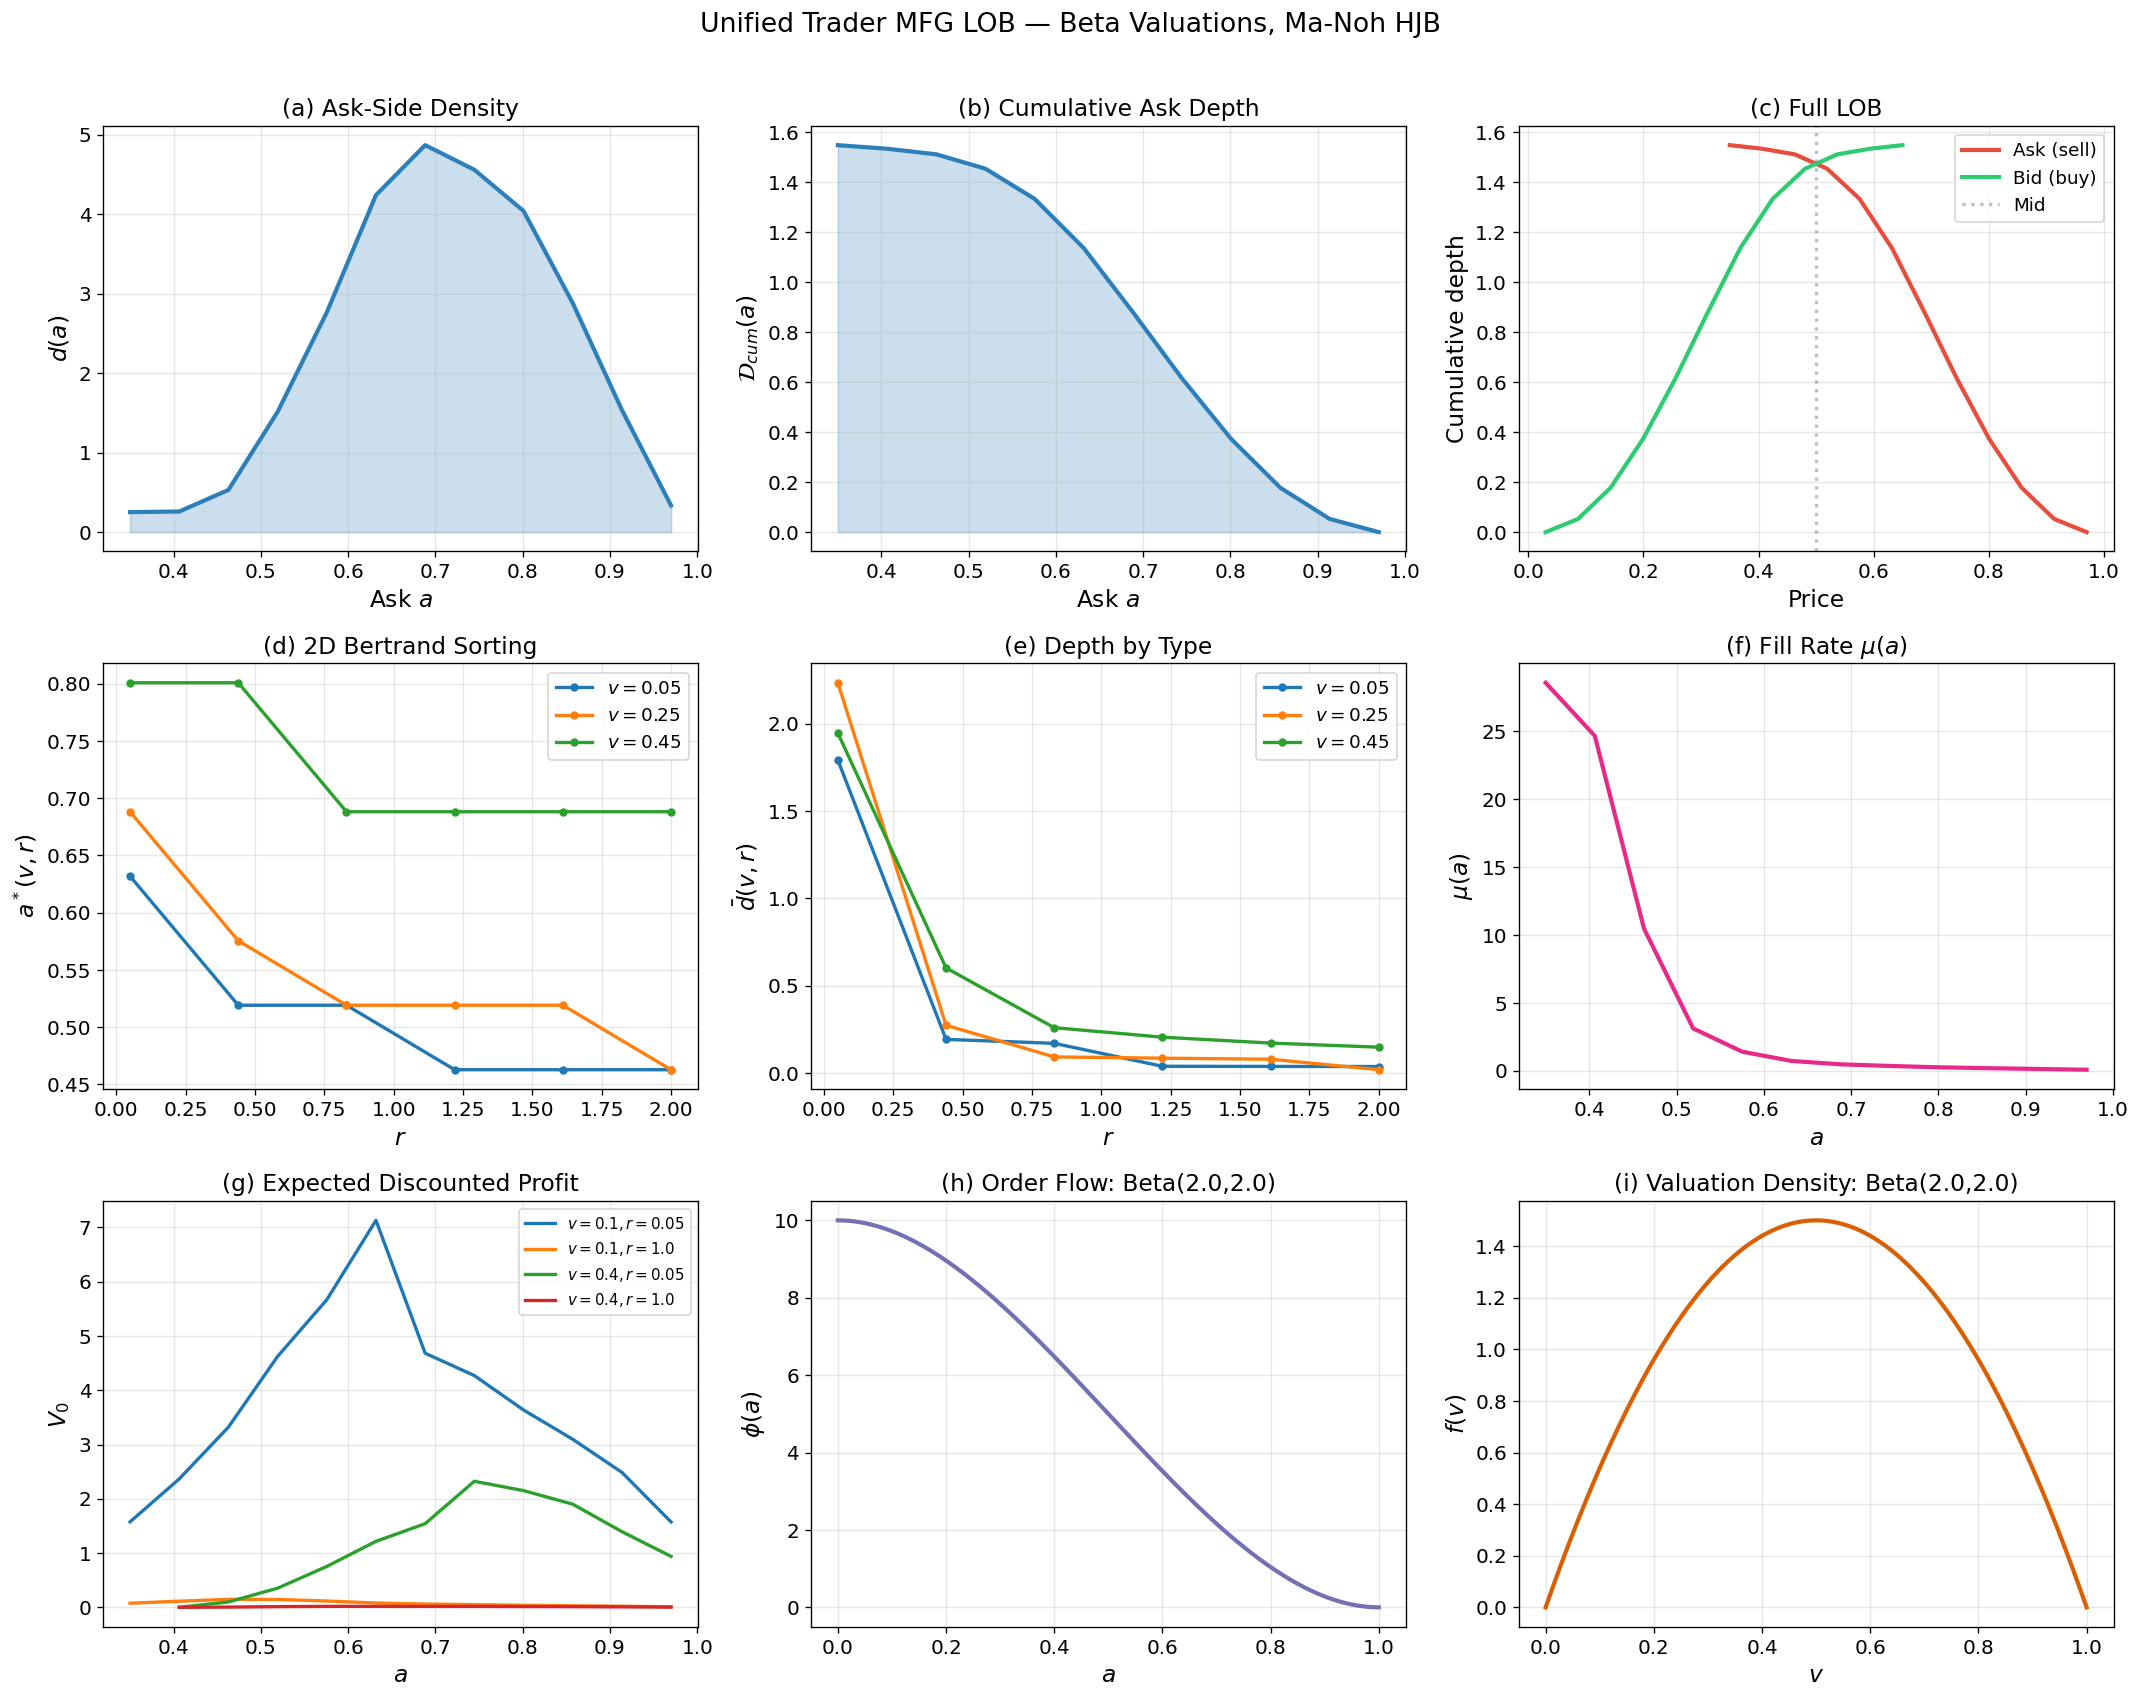

a*(v=0.25,r): DECREASING
D_max (density) = 4.868 at a = 0.688
Total ask depth = 1.549


In [6]:
D_cum_ask = np.zeros(N_a)
for i in range(N_a):
    D_cum_ask[i] = np.trapz(D_final[i:], a_grid[i:]) if len(a_grid[i:])>1 else 0

# Bid side by symmetry
b_grid = 1.0 - a_grid[::-1]
D_bid_density = D_final[::-1]
D_cum_bid = np.zeros(N_a)
for i in range(N_a):
    D_cum_bid[i] = np.trapz(D_bid_density[:i+1], b_grid[:i+1]) if i>0 else 0

# Value landscape
V0_land = {}
for v_sel,r_sel in [(0.10,0.05),(0.10,1.0),(0.40,0.05),(0.40,1.0)]:
    V0a = np.full(N_a, np.nan)
    for j in range(N_a):
        if a_grid[j]-v_sel<=0.001: continue
        V0a[j],_ = solve_manoh_at_price(a_grid[j],v_sel,r_sel,mu_final[j],inner_iters=10)
    V0_land[(v_sel,r_sel)] = V0a

fig = plt.figure(figsize=(18, 14))

ax1=fig.add_subplot(3,3,1)
ax1.plot(a_grid,D_final,color='#2c7fb8',lw=2.5)
ax1.fill_between(a_grid,0,D_final,alpha=0.25,color='#2c7fb8')
ax1.set_xlabel('Ask $a$'); ax1.set_ylabel('$d(a)$')
ax1.set_title('(a) Ask-Side Density'); ax1.grid(True,alpha=0.3)

ax2=fig.add_subplot(3,3,2)
ax2.plot(a_grid,D_cum_ask,color='#2c7fb8',lw=2.5)
ax2.fill_between(a_grid,0,D_cum_ask,alpha=0.25,color='#2c7fb8')
ax2.set_xlabel('Ask $a$'); ax2.set_ylabel(r'$\mathcal{D}_{cum}(a)$')
ax2.set_title('(b) Cumulative Ask Depth'); ax2.grid(True,alpha=0.3)

ax3=fig.add_subplot(3,3,3)
ax3.plot(a_grid,D_cum_ask,color='#e74c3c',lw=2.5,label='Ask (sell)')
ax3.plot(b_grid,D_cum_bid,color='#2ecc71',lw=2.5,label='Bid (buy)')
ax3.axvline(0.5,color='gray',ls=':',alpha=0.5,label='Mid')
ax3.set_xlabel('Price'); ax3.set_ylabel('Cumulative depth')
ax3.set_title('(c) Full LOB'); ax3.legend(); ax3.grid(True,alpha=0.3)

ax4=fig.add_subplot(3,3,4)
for kv in [0,N_v//2,N_v-1]:
    ax4.plot(r_grid,a_star_2d[kv,:],'o-',ms=4,label=f'$v={v_grid[kv]:.2f}$')
ax4.set_xlabel('$r$'); ax4.set_ylabel('$a^*(v,r)$')
ax4.set_title('(d) 2D Bertrand Sorting'); ax4.legend(); ax4.grid(True,alpha=0.3)

ax5=fig.add_subplot(3,3,5)
for kv in [0,N_v//2,N_v-1]:
    ax5.plot(r_grid,d_bar_2d[kv,:],'o-',ms=4,label=f'$v={v_grid[kv]:.2f}$')
ax5.set_xlabel('$r$'); ax5.set_ylabel(r'$\bar{d}(v,r)$')
ax5.set_title('(e) Depth by Type'); ax5.legend(); ax5.grid(True,alpha=0.3)

ax6=fig.add_subplot(3,3,6)
ax6.plot(a_grid,mu_final,color='#e7298a',lw=2.5)
ax6.set_xlabel('$a$'); ax6.set_ylabel(r'$\mu(a)$')
ax6.set_title(r'(f) Fill Rate $\mu(a)$'); ax6.grid(True,alpha=0.3)

ax7=fig.add_subplot(3,3,7)
for (vs,rs),V0a in V0_land.items():
    ax7.plot(a_grid,V0a,lw=2,label=f'$v={vs},r={rs}$')
ax7.set_xlabel('$a$'); ax7.set_ylabel('$V_0$')
ax7.set_title('(g) Expected Discounted Profit'); ax7.legend(fontsize=9); ax7.grid(True,alpha=0.3)

ax8=fig.add_subplot(3,3,8)
a_fine=np.linspace(0,1,200)
ax8.plot(a_fine,phi_flow(a_fine),color='#7570b3',lw=2.5)
ax8.set_xlabel('$a$'); ax8.set_ylabel(r'$\phi(a)$')
ax8.set_title(rf'(h) Order Flow: Beta({alpha_F},{beta_F})'); ax8.grid(True,alpha=0.3)

ax9=fig.add_subplot(3,3,9)
ax9.plot(a_fine,beta_dist.pdf(a_fine,alpha_F,beta_F),color='#d95f02',lw=2.5)
ax9.set_xlabel('$v$'); ax9.set_ylabel('$f(v)$')
ax9.set_title(rf'(i) Valuation Density: Beta({alpha_F},{beta_F})'); ax9.grid(True,alpha=0.3)

fig.suptitle(r'Unified Trader MFG LOB — Beta Valuations, Ma-Noh HJB', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

d=np.diff(a_star_2d[N_v//2,:])
mono='DECREASING' if np.all(d<=1e-6) else ('INCREASING' if np.all(d>=-1e-6) else 'NON-MONOTONE')
print(f'a*(v={v_grid[N_v//2]:.2f},r): {mono}')
print(f'D_max (density) = {D_final.max():.3f} at a = {a_grid[np.argmax(D_final)]:.3f}')
print(f'Total ask depth = {D_cum_ask[0]:.3f}')

## §12. Reading the Results

### Panel (a): Ask-side density $d(a)$
The **density** of posted depth across ask prices. This is the derivative of the cumulative LOB — it shows where depth is concentrated. The hump shape reflects the Bertrand sorting of heterogeneous LPs.

### Panel (b): Cumulative ask depth $\mathcal{D}_{\text{cum}}(a)$
The **integral** of $d(a)$ from $a$ to $a_{\max}$: total shares available at ask $a$ or above. This is what you see on a Polymarket order book screenshot. It starts at the total depth and decreases to zero at the top of the book.

### Panel (c): Full LOB
Both sides of the book, using the YES/NO symmetry: $d_{\text{bid}}(b) = d_{\text{ask}}(1-b)$. The ask side (red) and bid side (green) mirror each other around mid-price 0.5 (for symmetric Beta(2,2)).

### Panel (d): 2D Bertrand sorting
The optimal ask $a^*(v, r)$ depends on both valuation and patience:
- **Lower $v$** (blue, $v=0.05$): large margin → LP can afford to post at various levels
- **Higher $v$** (green, $v=0.45$): thin margin → forced to post at high $a$ just to break even
- **Lower $r$**: patient → posts higher $a$ for larger per-fill profit
- **Higher $r$**: impatient → posts lower $a$ for quick fills

### Panel (g): Value landscape $V_0(v, r, a)$
The blue curve ($v=0.10, r=0.05$: bearish + patient) has the highest value — this LP can post profitably across a wide range and chooses the peak. The red curve ($v=0.40, r=1.0$: neutral + impatient) is nearly flat and close to zero.

### Panels (h)–(i): Primitives
The Beta(2,2) distribution and the resulting order flow $\phi(a)$. These determine both the demand hitting the book and the supply of LP cost bases.

## §13. Next Steps

1. **Calibrate $F$** to Polymarket order flow data (Beta parameters from observed trade rates)
2. **No-arbitrage + fees**: constrain $a \ge \max(c/(1-f), (1+f)/2)$ using Polymarket commission $f$
3. **Pareto $G(r)$** for LP discount rates (few patient market makers + retail tail)
4. **Continuum limit** $N \to \infty$: replace discrete aggregation with smooth integral equation
5. **Non-symmetric contracts**: use Beta$(\alpha_F, \beta_F)$ with $\alpha_F \ne \beta_F$ for near-certain events
6. **Price dynamics**: informational efficiency via endogenous depth-scaled impact